# Refactored Hybrid Model: PhoBERT + SentiWordNet Light Fusion\n\n## Design goals\n1. Keep PhoBERT close to the strong baseline by using the CLS token directly.\n2. Keep SentiWordNet as a compact auxiliary signal with interpretable cues.\n3. Compare simple concatenation against optional gated fusion.\n4. Make class weighting and selection metrics easy to change.


## 1. Setup và Import Libraries

In [2]:
import os, sys, json, time, random, copy
from pathlib import Path
from datetime import datetime
from collections import Counter

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except ImportError:
    drive = None

if IN_COLAB:
    drive.mount('/content/drive')

def find_project_root():
    if IN_COLAB:
        root = Path('/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis')
        if root.exists():
            return root
        raise FileNotFoundError(root)
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists() and (candidate / 'results').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Mounted at /content/drive
Project root: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis


In [3]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
    precision_score, recall_score, precision_recall_fscore_support
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from tqdm import tqdm
from IPython.display import display
from src.data_utils import (
    load_data, load_sentiwordnet, preprocess_vietnamese,
    extract_swn_features_extended_batch, SWN_EXTENDED_FEATURE_NAMES
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

In [4]:
class Config:
    BASE_DIR = str(PROJECT_ROOT)
    DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed')
    SENTIWORDNET_FILE = os.path.join(BASE_DIR, 'data', 'sentiwordnet-dataset', 'VietSentiWordnet_Ver1.3.5.txt')
    MODEL_TYPE = 'PhoBERT_Sentiwordnet_Refactored_LightFusion'
    EXPERIMENT_TYPE = 'improvements'
    TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
    RESULTS_DIR = os.path.join(BASE_DIR, 'results', MODEL_TYPE, EXPERIMENT_TYPE, TIMESTAMP)
    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')
    MODEL_NAME = 'vinai/phobert-base'
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    NUM_CLASSES = 3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    MAX_LENGTH = 256
    BATCH_SIZE = 32
    DROPOUT = 0.3
    FUSION_MODE = 'concat'
    # MUST match checkpoint: pretrained model used SWN_PROJ_DIM=128
    SWN_PROJ_DIM = 128
    CLASSIFIER_HIDDEN_DIM = 256
    SELECTION_METRIC = 'f1_macro'
    CLASS_WEIGHT_MODE = 'sqrt_balanced'
    # Pretrained checkpoint path
    PRETRAINED_CKPT = os.path.join(BASE_DIR, 'results', 'PhoBERT_Sentiwordnet_Refactored_LightFusion', 'improvements', '20260322_045916', 'models', 'best_model.pt')

config = Config()
for path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR, config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(path, exist_ok=True)

assert config.FUSION_MODE in {'concat', 'gated'}
assert config.SELECTION_METRIC in {'f1_macro', 'f1_weighted'}
assert config.CLASS_WEIGHT_MODE in {'none', 'sqrt_balanced', 'log1p_balanced', 'balanced'}

print('=' * 60)
print('REFACTORED CONFIGURATION')
print('=' * 60)
print(f'Model: {config.MODEL_NAME}')
print(f'Fusion Mode: {config.FUSION_MODE}')
print(f'SWN Projection Dim: {config.SWN_PROJ_DIM}')
print(f'Pretrained Checkpoint: {config.PRETRAINED_CKPT}')
print(f'Device: {config.DEVICE}')

REFACTORED CONFIGURATION
Model: vinai/phobert-base
Fusion Mode: concat
SWN Projection Dim: 128
Pretrained Checkpoint: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet_Refactored_LightFusion/improvements/20260322_045916/models/best_model.pt
Device: cuda


## 3. Load Data

In [5]:
train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

print('Label distribution:')
for split_name, labels in [('Train', train_labels), ('Validation', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'{split_name}: total={len(labels)}')
    for idx, name in config.LABEL_MAP.items():
        count = counter.get(idx, 0)
        print(f'  {name}: {count} ({count/len(labels)*100:.1f}%)')

Label distribution:
Train: total=11426
  Negative: 5325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5643 (49.4%)
Validation: total=1583
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)
Test: total=3166
  Negative: 1409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1590 (50.2%)


## 4. Load SentiWordNet & Build Compact Auxiliary Features


In [6]:
INTENSIFIER_WORDS = {'rất', 'quá', 'khá', 'hơi', 'siêu', 'cực', 'thật', 'thực_sự', 'vô_cùng'}
EXTRA_SENTIMENT_CUE_NAMES = ['exclamation_count', 'question_count', 'has_exclamation', 'has_question', 'intensifier_count', 'intensifier_ratio']
AUX_FEATURE_NAMES = SWN_EXTENDED_FEATURE_NAMES + EXTRA_SENTIMENT_CUE_NAMES


def extract_additional_sentiment_cues(text):
    words = preprocess_vietnamese(text).split()
    token_count = max(len(words), 1)
    exclamation_count = text.count('!')
    question_count = text.count('?')
    intensifier_count = sum(1 for word in words if word in INTENSIFIER_WORDS)
    return [
        exclamation_count,
        question_count,
        float(exclamation_count > 0),
        float(question_count > 0),
        intensifier_count,
        intensifier_count / token_count,
    ]


def build_swn_aux_features(texts, word_to_scores):
    base_features = extract_swn_features_extended_batch(texts, word_to_scores).astype(np.float32)
    extra_cues = np.array([extract_additional_sentiment_cues(text) for text in texts], dtype=np.float32)
    return np.concatenate([base_features, extra_cues], axis=1)


print('Loading VietSentiWordNet lexicon...')
word_to_scores = load_sentiwordnet(config.SENTIWORDNET_FILE)
print(f'Loaded {len(word_to_scores)} words')
print('\nExtracting compact SentiWordNet + cue features...')
train_swn = build_swn_aux_features(train_texts, word_to_scores)
val_swn = build_swn_aux_features(val_texts, word_to_scores)
test_swn = build_swn_aux_features(test_texts, word_to_scores)
print(f'Auxiliary feature shape: Train={train_swn.shape}, Val={val_swn.shape}, Test={test_swn.shape}')
print('Key cues included: pos/neg counts, ratios, negation signals, punctuation cues, and intensifier indicators.')
swn_scaler = StandardScaler()
train_swn_scaled = swn_scaler.fit_transform(train_swn).astype(np.float32)
val_swn_scaled = swn_scaler.transform(val_swn).astype(np.float32)
test_swn_scaled = swn_scaler.transform(test_swn).astype(np.float32)
joblib.dump(swn_scaler, os.path.join(config.ARTIFACTS_DIR, 'swn_scaler.pkl'))
with open(os.path.join(config.ARTIFACTS_DIR, 'swn_feature_names.json'), 'w', encoding='utf-8') as f:
    json.dump(AUX_FEATURE_NAMES, f, ensure_ascii=False, indent=2)


Loading VietSentiWordNet lexicon...
Loaded 1227 words

Extracting compact SentiWordNet + cue features...
Auxiliary feature shape: Train=(11426, 41), Val=(1583, 41), Test=(3166, 41)
Key cues included: pos/neg counts, ratios, negation signals, punctuation cues, and intensifier indicators.


## 5. Dataset & Model Definition


In [7]:
class HybridDataset(Dataset):
    """Dataset that returns PhoBERT inputs plus compact sentiment lexicon features."""
    def __init__(self, texts, swn_features, labels, tokenizer, max_length):
        self.texts = texts
        self.swn_features = swn_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'swn_features': torch.tensor(self.swn_features[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [8]:
class PhoBERTSentiWordNetLightHybrid(nn.Module):
    """PhoBERT-first hybrid with a compact interpretable sentiment-feature branch."""
    def __init__(self, model_name, num_classes, swn_dim, fusion_mode='concat', dropout=0.3):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        self.fusion_mode = fusion_mode
        phobert_dim = self.phobert.config.hidden_size
        self.phobert_dropout = nn.Dropout(dropout)
        self.swn_projection = nn.Sequential(
            nn.Linear(swn_dim, config.SWN_PROJ_DIM),
            nn.LayerNorm(config.SWN_PROJ_DIM),
            nn.SiLU(),
            nn.Dropout(dropout)
        )
        combined_dim = phobert_dim + config.SWN_PROJ_DIM
        if fusion_mode == 'gated':
            self.aux_gate = nn.Linear(combined_dim, config.SWN_PROJ_DIM)
            nn.init.constant_(self.aux_gate.bias, -1.0)
        else:
            self.aux_gate = None
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(combined_dim, config.CLASSIFIER_HIDDEN_DIM),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(config.CLASSIFIER_HIDDEN_DIM, num_classes)
        )

    def get_head_modules(self):
        modules = [self.swn_projection, self.classifier]
        if self.aux_gate is not None:
            modules.append(self.aux_gate)
        return modules

    def forward(self, input_ids, attention_mask, swn_features):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        phobert_cls = self.phobert_dropout(outputs.last_hidden_state[:, 0, :])
        swn_projected = self.swn_projection(swn_features)
        if self.aux_gate is not None:
            gate = torch.sigmoid(self.aux_gate(torch.cat([phobert_cls, swn_projected], dim=1)))
            swn_projected = swn_projected * gate
        return self.classifier(torch.cat([phobert_cls, swn_projected], dim=1))


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
model = PhoBERTSentiWordNetLightHybrid(
    model_name=config.MODEL_NAME,
    num_classes=config.NUM_CLASSES,
    swn_dim=train_swn_scaled.shape[1],
    fusion_mode=config.FUSION_MODE,
    dropout=config.DROPOUT
).to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Auxiliary feature dim: {train_swn_scaled.shape[1]}')
print(f'Total parameters: {total_params:,}')
print(f'Initial trainable parameters: {count_trainable_params(model):,}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Auxiliary feature dim: 41
Total parameters: 135,234,307
Initial trainable parameters: 135,234,307


## 6. Create DataLoaders


In [9]:
train_dataset = HybridDataset(train_texts, train_swn_scaled, train_labels, tokenizer, config.MAX_LENGTH)
val_dataset = HybridDataset(val_texts, val_swn_scaled, val_labels, tokenizer, config.MAX_LENGTH)
test_dataset = HybridDataset(test_texts, test_swn_scaled, test_labels, tokenizer, config.MAX_LENGTH)
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')


Train batches: 358
Val batches: 50
Test batches: 99


<cell_type>markdown</cell_type>## 7. Evaluate Function

In [10]:
def evaluate(model, dataloader, device):
    """Evaluate model and return predictions and metrics."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            swn_features = batch['swn_features'].to(device)
            labels = batch['label'].to(device)
            logits = model(input_ids, attention_mask, swn_features)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(
        all_labels, all_preds, labels=[0, 1, 2], zero_division=0
    )
    return {
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1_macro': f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1_weighted': f1_score(all_labels, all_preds, average='weighted', zero_division=0),
        'precision_per_class': precision_pc.tolist(),
        'recall_per_class': recall_pc.tolist(),
        'f1_per_class': f1_pc.tolist(),
        'support_per_class': support_pc.tolist(),
        'confusion_matrix': confusion_matrix(all_labels, all_preds, labels=[0, 1, 2]).tolist(),
        'classification_report_text': classification_report(all_labels, all_preds, labels=[0, 1, 2], target_names=list(config.LABEL_MAP.values()), zero_division=0),
        'y_pred': list(map(int, all_preds)),
        'y_true': list(map(int, all_labels)),
    }

<cell_type>markdown</cell_type>## 8. Load Pretrained Model and Get Topic-wise Results

Checkpoint duoc nap: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet_Refactored_LightFusion/improvements/20260322_045916/models/best_model.pt



=== Overall Test Metrics ===
Accuracy: 0.9318
F1 Macro: 0.8308
F1 Weighted: 0.9302

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.96      0.95      1409
     Neutral       0.65      0.54      0.59       167
    Positive       0.96      0.94      0.95      1590

    accuracy                           0.93      3166
   macro avg       0.85      0.82      0.83      3166
weighted avg       0.93      0.93      0.93      3166


=== Topic-wise Results ===


,topic_id,topic_name,samples,accuracy,f1_macro,f1_weighted
0,0,Giang vien,2290,0.946725,0.836997,0.945677
1,1,Chuong trinh dao tao,572,0.889860,0.740618,0.885015
2,2,Co so vat chat,145,0.986207,0.832121,0.986194
3,3,Khac,159,0.817610,0.809925,0.817425



--- Topic 0 (Giang vien) ---
              precision    recall  f1-score   support

    Negative       0.93      0.97      0.95       791
     Neutral       0.68      0.54      0.60        74
    Positive       0.97      0.96      0.96      1425

    accuracy                           0.95      2290
   macro avg       0.86      0.82      0.84      2290
weighted avg       0.95      0.95      0.95      2290


--- Topic 1 (Chuong trinh dao tao) ---
              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95       416
     Neutral       0.51      0.38      0.44        47
    Positive       0.82      0.85      0.83       109

    accuracy                           0.89       572
   macro avg       0.76      0.73      0.74       572
weighted avg       0.88      0.89      0.89       572


--- Topic 2 (Co so vat chat) ---
              precision    recall  f1-score   support

    Negative       1.00      0.99      1.00       138
     Neutral       1.00  

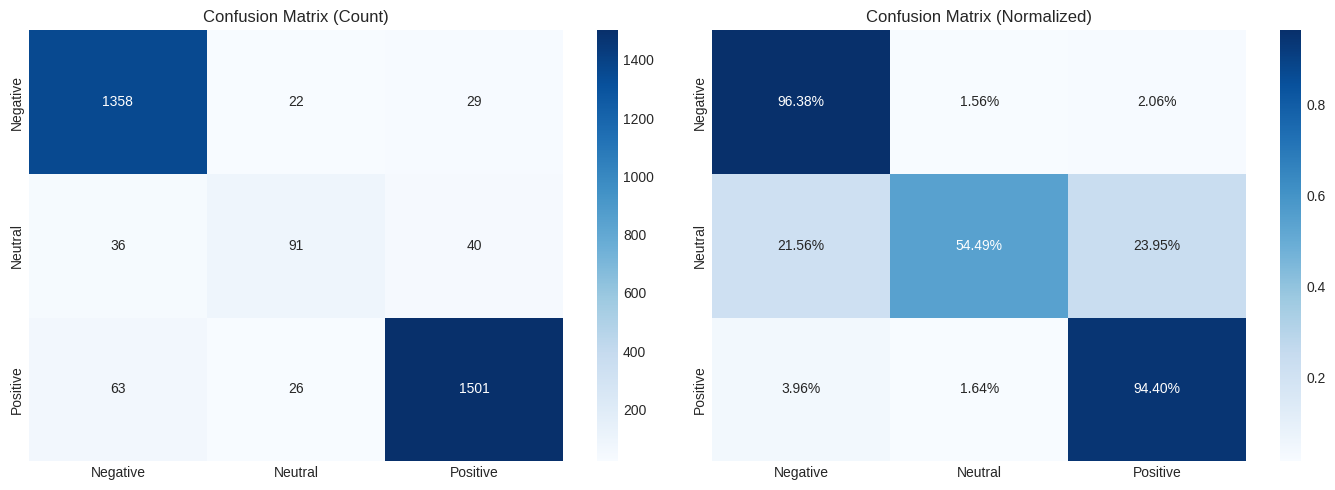

In [11]:
def load_topics(data_dir, split):
    split_dir = os.path.join(data_dir, split)
    with open(os.path.join(split_dir, 'topics.txt'), 'r', encoding='utf-8') as f:
        return [int(line.strip()) for line in f.readlines()]


def load_checkpoint_safe(model_obj, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
    cleaned = {}
    for k, v in state_dict.items():
        nk = k[7:] if k.startswith('module.') else k
        cleaned[nk] = v
    model_obj.load_state_dict(cleaned, strict=False)


TOPIC_MAP = {0: 'Giang vien', 1: 'Chuong trinh dao tao', 2: 'Co so vat chat', 3: 'Khac'}

# Load pretrained checkpoint
ckpt_path = config.PRETRAINED_CKPT
if not os.path.exists(ckpt_path):
    raise FileNotFoundError(f'Khong tim thay checkpoint: {ckpt_path}')

print(f'Checkpoint duoc nap: {ckpt_path}')
load_checkpoint_safe(model, ckpt_path, config.DEVICE)
model.eval()

# Evaluate test set
test_results = evaluate(model, test_loader, config.DEVICE)
print('\n=== Overall Test Metrics ===')
print(f"Accuracy: {test_results['accuracy']:.4f}")
print(f"F1 Macro: {test_results['f1_macro']:.4f}")
print(f"F1 Weighted: {test_results['f1_weighted']:.4f}")
print('\nClassification Report:')
print(test_results['classification_report_text'])

# Topic-wise results
test_topics = load_topics(config.DATA_DIR, 'test')
if len(test_topics) != len(test_results['y_true']):
    raise ValueError(f'Mismatch do dai: topics={len(test_topics)} vs y_true={len(test_results["y_true"])}')

topic_df = pd.DataFrame({
    'topic': test_topics,
    'y_true': test_results['y_true'],
    'y_pred': test_results['y_pred']
})

topic_rows = []
for topic_id in sorted(topic_df['topic'].unique()):
    sub = topic_df[topic_df['topic'] == topic_id]
    acc = accuracy_score(sub['y_true'], sub['y_pred'])
    f1m = f1_score(sub['y_true'], sub['y_pred'], average='macro', zero_division=0)
    f1w = f1_score(sub['y_true'], sub['y_pred'], average='weighted', zero_division=0)
    topic_rows.append({
        'topic_id': int(topic_id),
        'topic_name': TOPIC_MAP.get(int(topic_id), str(topic_id)),
        'samples': int(len(sub)),
        'accuracy': float(acc),
        'f1_macro': float(f1m),
        'f1_weighted': float(f1w),
    })

print('\n=== Topic-wise Results ===')
topic_metrics_df = pd.DataFrame(topic_rows).sort_values('topic_id')
display(topic_metrics_df)

for topic_id in sorted(topic_df['topic'].unique()):
    sub = topic_df[topic_df['topic'] == topic_id]
    print(f"\n--- Topic {topic_id} ({TOPIC_MAP.get(int(topic_id), str(topic_id))}) ---")
    print(classification_report(sub['y_true'], sub['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))

# Save results
os.makedirs(config.SUMMARIES_DIR, exist_ok=True)
topic_metrics_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'topic_metrics_from_pretrained.csv'), index=False)
topic_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'topic_predictions_test.csv'), index=False)
print('\nDa luu file: topic_metrics_from_pretrained.csv, topic_predictions_test.csv')

# Confusion Matrix visualization
cm = np.array(test_results['confusion_matrix'])
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(config.LABEL_MAP.values()), yticklabels=list(config.LABEL_MAP.values()), ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=list(config.LABEL_MAP.values()), yticklabels=list(config.LABEL_MAP.values()), ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix_pretrained.png'), dpi=150, bbox_inches='tight')
plt.show()

## Topic-wise Visualizations

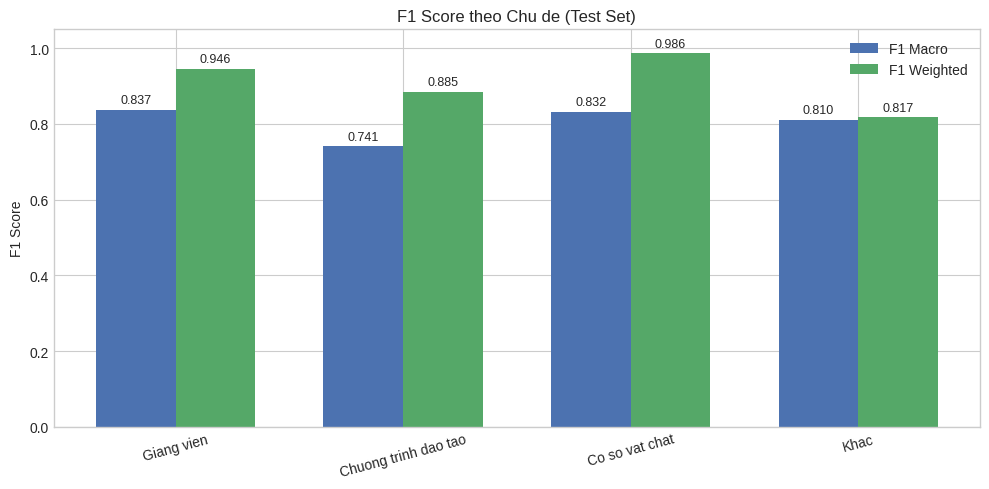

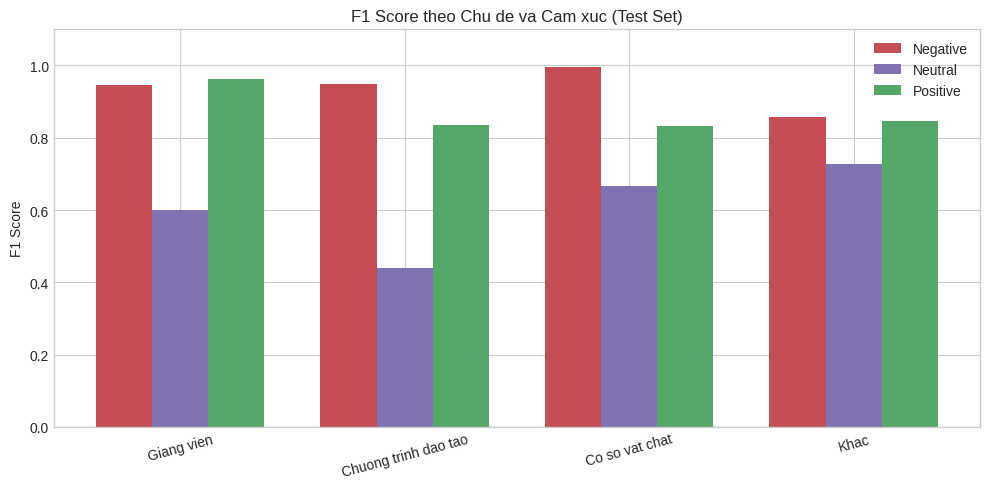

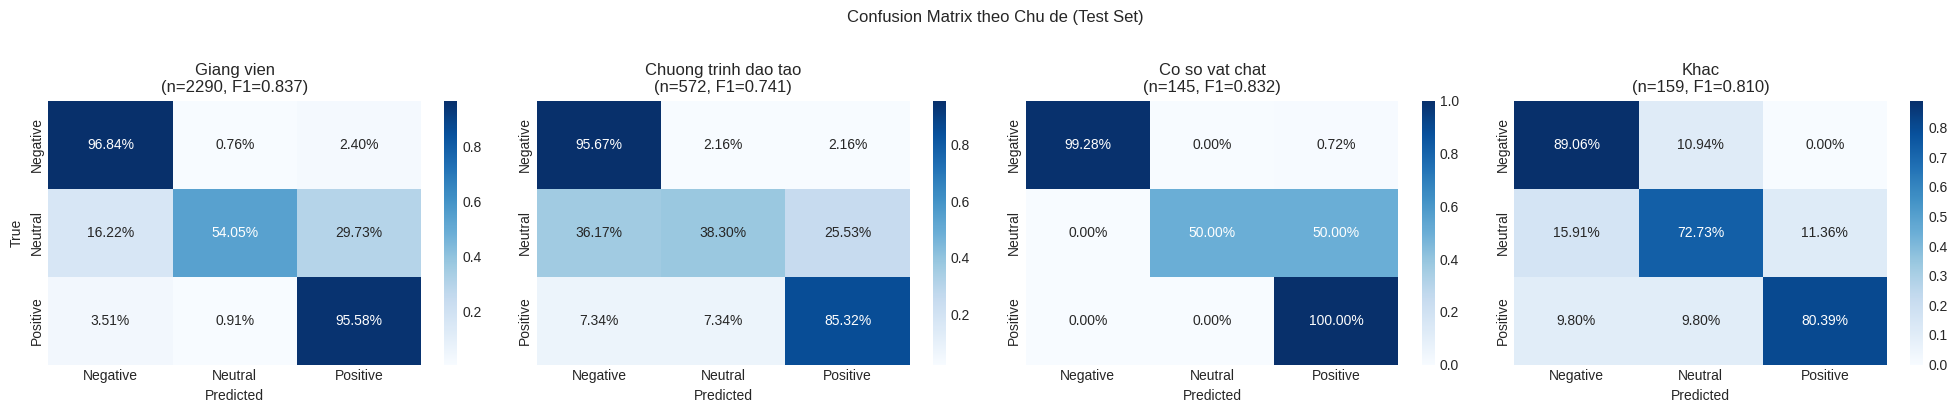

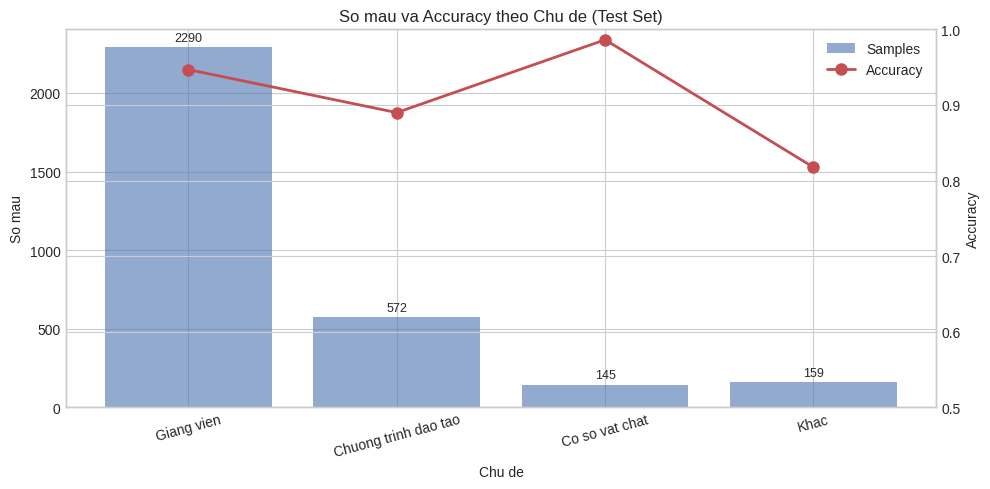

Da luu tat ca bieu do topic-wise vao: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_Sentiwordnet_Refactored_LightFusion/improvements/20260329_090750/visualizations


In [12]:
# === Topic-wise visualizations ===

# Compute per-sentiment F1 for each topic
topic_rows_detail = []
for topic_id in sorted(topic_df['topic'].unique()):
    sub = topic_df[topic_df['topic'] == topic_id]
    p, r, f1, support = precision_recall_fscore_support(
        sub['y_true'], sub['y_pred'], labels=[0, 1, 2], zero_division=0
    )
    topic_rows_detail.append({
        'topic_id': int(topic_id),
        'topic_name': TOPIC_MAP.get(int(topic_id), str(topic_id)),
        'samples': int(len(sub)),
        'accuracy': float(accuracy_score(sub['y_true'], sub['y_pred'])),
        'f1_macro': float(f1_score(sub['y_true'], sub['y_pred'], average='macro', zero_division=0)),
        'f1_weighted': float(f1_score(sub['y_true'], sub['y_pred'], average='weighted', zero_division=0)),
        'f1_negative': float(f1[0]),
        'f1_neutral': float(f1[1]),
        'f1_positive': float(f1[2]),
    })
topic_viz_df = pd.DataFrame(topic_rows_detail).sort_values('topic_id')

# 1) F1 macro/weighted per topic
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(topic_viz_df))
width = 0.35
bars1 = ax.bar(x - width/2, topic_viz_df['f1_macro'], width, label='F1 Macro', color='#4C72B0')
bars2 = ax.bar(x + width/2, topic_viz_df['f1_weighted'], width, label='F1 Weighted', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(topic_viz_df['topic_name'], rotation=15)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.set_title('F1 Score theo Chu de (Test Set)')
ax.legend()
for b in bars1:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for b in bars2:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_f1_scores.png'), dpi=150, bbox_inches='tight')
plt.show()

# 2) Per-topic per-sentiment F1
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(topic_viz_df))
width = 0.25
ax.bar(x - width, topic_viz_df['f1_negative'], width, label='Negative', color='#C44E52')
ax.bar(x, topic_viz_df['f1_neutral'], width, label='Neutral', color='#8172B2')
ax.bar(x + width, topic_viz_df['f1_positive'], width, label='Positive', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(topic_viz_df['topic_name'], rotation=15)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('F1 Score theo Chu de va Cam xuc (Test Set)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_sentiment_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

# 3) Confusion matrix per topic
fig, axes = plt.subplots(1, len(topic_viz_df), figsize=(5 * len(topic_viz_df), 4))
label_names = list(config.LABEL_MAP.values())
for i, row in topic_viz_df.iterrows():
    sub = topic_df[topic_df['topic'] == row['topic_id']]
    cm_topic = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0, 1, 2])
    cm_topic_norm = cm_topic.astype(float) / cm_topic.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_topic_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[i])
    axes[i].set_title(f"{row['topic_name']}\n(n={row['samples']}, F1={row['f1_macro']:.3f})")
    if i == 0:
        axes[i].set_ylabel('True')
    axes[i].set_xlabel('Predicted')
plt.suptitle('Confusion Matrix theo Chu de (Test Set)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

# 4) Sample count + accuracy per topic
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
bars = ax1.bar(x, topic_viz_df['samples'], color='#4C72B0', alpha=0.6, label='Samples')
ax1.set_ylabel('So mau')
ax1.set_xlabel('Chu de')
ax1.set_xticks(x)
ax1.set_xticklabels(topic_viz_df['topic_name'], rotation=15)
ax2.plot(x, topic_viz_df['accuracy'], 'o-', color='#C44E52', linewidth=2, markersize=8, label='Accuracy')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.5, 1.0)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')
ax1.set_title('So mau va Accuracy theo Chu de (Test Set)')
for b in bars:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 20, f'{int(b.get_height())}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_samples_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Da luu tat ca bieu do topic-wise vao:', config.VISUALIZATIONS_DIR)